[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/benchmark_diagnostics_gsm8k.ipynb)

# Benchmark Diagnostics: Detecting Invalid Questions in GSM8K

AI benchmarks drive model development, but they often contain invalid questions: wrong answer keys,
ambiguous wording, or grading errors. Manually reviewing thousands of questions is infeasible.

[Truong et al. (2025)](https://arxiv.org/abs/2511.16842) introduced a framework that uses
measurement-theoretic statistics derived from LLM response patterns to flag potentially invalid
questions for expert review. The key insight: if sum scores are a sufficient statistic for model
ability (implying a Rasch model), then certain inter-item and item-total statistics must be
non-negative. Items that violate these expectations are candidates for manual inspection.

This tutorial uses `torch_measure.diagnostics` to reproduce the GSM8K analysis from that paper,
applying all three signals to a real response matrix of 90 LLMs on 997 math questions.

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e "torch_measure[data]" datasets
except ImportError:
    pass  # Already installed locally

# Prevent mutex deadlock from sentence_transformers' Rust tokenizer on macOS.
# Only needed when running locally; Colab does not hit this issue.
import sys, types
if "sentence_transformers" not in sys.modules:
    _mock = types.ModuleType("sentence_transformers")
    _mock.SentenceTransformer = type("SentenceTransformer", (), {})
    sys.modules["sentence_transformers"] = _mock

import pickle
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download

from torch_measure.diagnostics import (
    average_tetrachoric_correlation,
    flag_items,
    item_scalability,
    item_total_correlation,
)

plt.rcParams["figure.dpi"] = 100
print("Imports OK")

Imports OK


## 2. Load the GSM8K Response Matrix

The response data comes from the
[stair-lab/fantastic-bugs](https://huggingface.co/datasets/stair-lab/fantastic-bugs)
dataset on HuggingFace. The raw pickle file contains a `pandas.DataFrame` with 90 LLMs
as rows and 997 GSM8K questions as columns. Each cell is binary: 1 if the LLM answered
correctly, 0 otherwise.

Ground truth labels come from GSM8K-Platinum (Vendrow et al. 2025), which identified 88
of the 997 questions as invalid. These labels are embedded in the DataFrame's column metadata.

In [2]:
pkl_path = hf_hub_download(
    repo_id="stair-lab/fantastic-bugs",
    filename="raw/lite_gsm_results_enhanced.pkl",
    repo_type="dataset",
)
with open(pkl_path, "rb") as f:
    df = pickle.load(f)

# The DataFrame has a 7-level MultiIndex on columns.
# Level 0 ("input.text"): question text
# Level 6 ("platinum_label"): 1 = valid, 0 = invalid per GSM8K-Platinum
question_texts = [col[0] for col in df.columns]
platinum_labels = np.array([col[6] for col in df.columns])  # 0 = invalid, 1 = valid
invalid_mask = platinum_labels == 0
llm_names = list(df.index)

response_matrix = torch.tensor(df.values, dtype=torch.float32)

n_llms, n_items = response_matrix.shape
n_invalid = int(invalid_mask.sum())

print(f"Response matrix: {n_llms} LLMs x {n_items} questions")
print(f"Overall accuracy: {response_matrix.mean():.3f}")
print(f"Invalid questions (GSM8K-Platinum): {n_invalid} / {n_items} ({100*n_invalid/n_items:.1f}%)")
print(f"\nFirst 5 LLMs: {llm_names[:5]}")
print(f"Last 5 LLMs:  {llm_names[-5:]}")

Response matrix: 90 LLMs x 997 questions
Overall accuracy: 0.676
Invalid questions (GSM8K-Platinum): 88 / 997 (8.8%)

First 5 LLMs: ['allenai/olmo-7b', 'cohere/command-light', 'AlephAlpha/luminous-base', 'cohere/command', 'meta/llama-3.1-8b-instruct-turbo']
Last 5 LLMs:  ['openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002', 'deepseek-ai/deepseek-v3', 'anthropic/claude-3-5-sonnet-20241022', 'anthropic/claude-3-5-sonnet-20240620']


## 3. Individual Signals

The paper derives three per-item statistics from the response matrix. Under a Rasch model,
all three are theoretically non-negative. Items with negative values violate this expectation
and are flagged as potentially invalid.

We compute each signal using `torch_measure.diagnostics` and visualize how invalid items
(per GSM8K-Platinum) distribute relative to valid ones.

In [3]:
tetra_scores = average_tetrachoric_correlation(response_matrix).numpy()
scalability_scores = item_scalability(response_matrix).numpy()
itc_scores = item_total_correlation(response_matrix).numpy()

print(f"Tetrachoric: {(tetra_scores < 0).sum()} items with negative avg correlation")
print(f"Scalability: {(scalability_scores < 0).sum()} items with negative Zj")
print(f"Item-total:  {(itc_scores < 0).sum()} items with negative correlation")

Tetrachoric: 3 items with negative avg correlation
Scalability: 5 items with negative Zj
Item-total:  5 items with negative correlation


### Signal distributions

The histograms below show each signal's distribution across all 997 items. Orange bars
mark items labeled invalid by GSM8K-Platinum. If the signals are working, invalid items
should concentrate on the left (negative) side of each distribution.

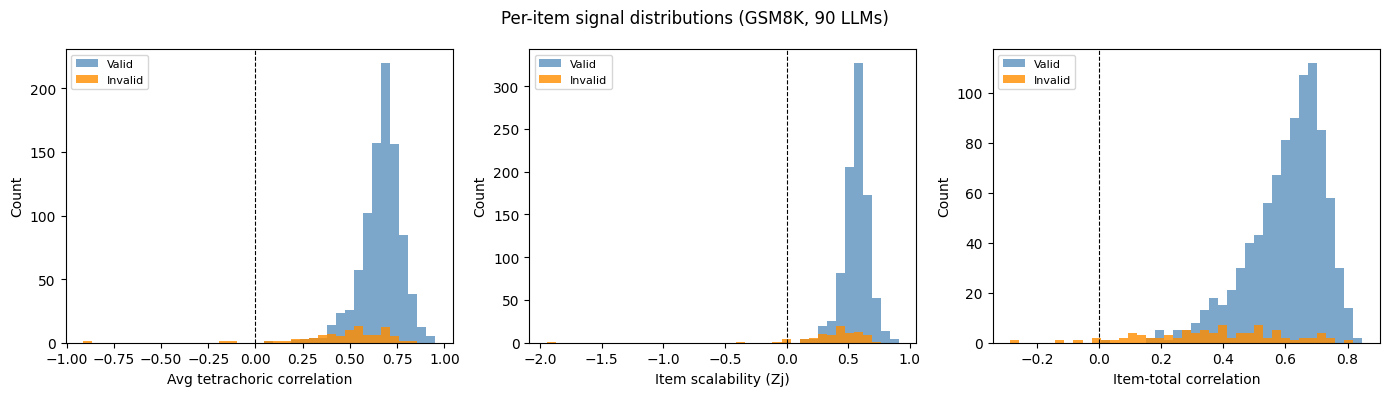

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

signal_data = [
    (tetra_scores, "Avg tetrachoric correlation"),
    (scalability_scores, "Item scalability (Zj)"),
    (itc_scores, "Item-total correlation"),
]

for ax, (scores, title) in zip(axes, signal_data):
    bins = np.linspace(scores.min() - 0.02, scores.max() + 0.02, 40)
    ax.hist(scores[~invalid_mask], bins=bins, alpha=0.7, label="Valid", color="steelblue")
    ax.hist(scores[invalid_mask], bins=bins, alpha=0.8, label="Invalid", color="darkorange")
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Per-item signal distributions (GSM8K, 90 LLMs)", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Ensemble Flagging and Evaluation

The three signals capture different aspects of item misfit. The paper combines them via a
Gaussian rank transform: each signal's raw values are ranked, converted to percentile positions,
and mapped through the inverse normal CDF. The ensemble score is the mean of these
transformed values across the three signals.

We use `flag_items()` to run the full pipeline.

In [5]:
result_df = flag_items(response_matrix, item_names=[f"Q{i}" for i in range(n_items)])

# Attach ground truth for evaluation
idx_order = result_df["item_idx"].values
result_df["is_invalid"] = invalid_mask[idx_order]

print(f"Flagged items: {result_df['flagged'].sum()} / {n_items}")
print(f"\nTop 10 items by ensemble anomaly score:")
display_cols = ["item_idx", "tetrachoric_score", "scalability_score", "item_total_score",
                "ensemble_score", "flagged", "is_invalid"]
print(result_df[display_cols].head(10).to_string(index=False))

Flagged items: 475 / 997

Top 10 items by ensemble anomaly score:
 item_idx  tetrachoric_score  scalability_score  item_total_score  ensemble_score  flagged  is_invalid
      549          -0.891566          -1.925668         -0.266569        3.289681     True        True
      478          -0.191906          -0.343982         -0.138488        2.966814     True        True
      749          -0.125984          -0.079505         -0.080075        2.806066     True        True
      667           0.175685          -0.005120         -0.001771        2.568251     True        True
      702           0.077108           0.012393          0.005914        2.564775     True       False
      861           0.254968          -0.028073         -0.005511        2.524663     True        True
      707           0.057522           0.028004          0.034248        2.519475     True        True
      106           0.126308           0.015121          0.006089        2.502349     True        True
      6

### Precision@k

Precision@k measures how many of the top-k flagged items are truly invalid.
This reflects a real-world scenario where a human expert has a limited budget
of k questions to review.

In [6]:
is_invalid_sorted = result_df["is_invalid"].values

for k in [10, 25, 50, 100]:
    tp = is_invalid_sorted[:k].sum()
    precision = tp / k
    print(f"Precision@{k:>3d}: {precision:.1%}  ({int(tp)} invalid in top {k})")

Precision@ 10: 90.0%  (9 invalid in top 10)
Precision@ 25: 64.0%  (16 invalid in top 25)
Precision@ 50: 52.0%  (26 invalid in top 50)
Precision@100: 42.0%  (42 invalid in top 100)


### Sensitivity curves

Sensitivity at inspection depth k is the fraction of all 88 invalid questions found
after inspecting the top k items ranked by anomaly score. This is the key evaluation
plot from Figure 1 (left) of the paper.

We plot one curve per signal plus the ensemble. A method that concentrates invalid
items near the top of the ranking will show a steep initial rise.

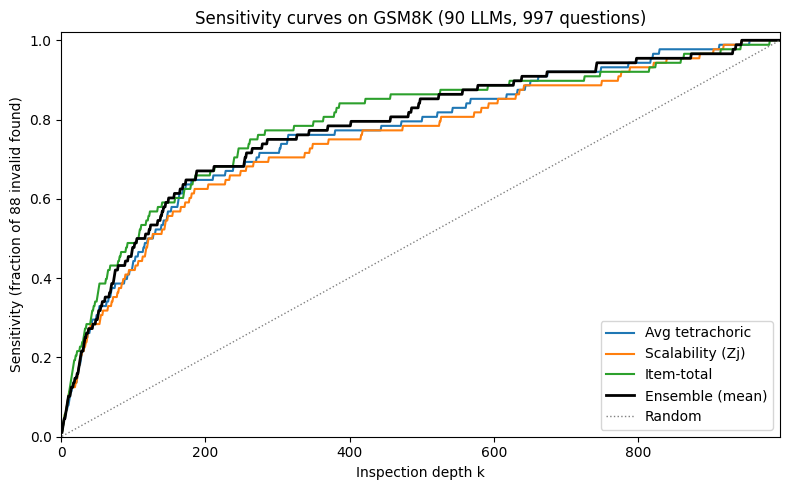

In [7]:
def sensitivity_curve(scores, invalid, negate=True):
    """Compute sensitivity at each inspection depth.

    Lower raw signal values are more anomalous under the Rasch model,
    so we negate by default to sort most-anomalous first.
    """
    order = np.argsort(-scores if negate else scores)[::-1]
    cumulative_tp = np.cumsum(invalid[order])
    total_invalid = invalid.sum()
    return cumulative_tp / total_invalid


ks = np.arange(1, n_items + 1)

sens_tetra = sensitivity_curve(tetra_scores, invalid_mask)
sens_scal = sensitivity_curve(scalability_scores, invalid_mask)
sens_itc = sensitivity_curve(itc_scores, invalid_mask)

# Ensemble: use the ensemble_score column (already sorted descending)
sens_ensemble = np.cumsum(is_invalid_sorted) / n_invalid

# Random baseline for reference
sens_random = ks / n_items

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, sens_tetra, label="Avg tetrachoric", linewidth=1.5)
ax.plot(ks, sens_scal, label="Scalability (Zj)", linewidth=1.5)
ax.plot(ks, sens_itc, label="Item-total", linewidth=1.5)
ax.plot(ks, sens_ensemble, label="Ensemble (mean)", linewidth=2, color="black")
ax.plot(ks, sens_random, label="Random", linestyle=":", color="gray", linewidth=1)

ax.set_xlabel("Inspection depth k")
ax.set_ylabel("Sensitivity (fraction of 88 invalid found)")
ax.set_title("Sensitivity curves on GSM8K (90 LLMs, 997 questions)")
ax.legend(loc="lower right")
ax.set_xlim(0, n_items)
ax.set_ylim(0, 1.02)
fig.tight_layout()
plt.show()

## 5. Inspecting Flagged Items

The statistical signals tell us *which* items are anomalous, but not *why*. Below we
print the actual question text and anomaly scores for the top 5 flagged items.

In [8]:
# Load expert reviews from the parquet split (16 reviewed items from the paper)
try:
    from datasets import load_dataset
    gsm_reviewed = load_dataset("stair-lab/fantastic-bugs", split="gsm")
    review_lookup = {row["question"]: row["review"] for row in gsm_reviewed}
    print(f"Loaded {len(review_lookup)} expert-reviewed items from the paper.\n")
except Exception:
    review_lookup = {}
    print("Expert reviews not available; showing questions and scores only.\n")

top_n = 5
top_indices = result_df["item_idx"].values[:top_n]

for rank, idx in enumerate(top_indices, 1):
    row = result_df[result_df["item_idx"] == idx].iloc[0]
    qtext = question_texts[idx]
    wrapped = textwrap.fill(qtext, width=90)

    print(f"--- Rank {rank} | Item {idx} | Ensemble score: {row['ensemble_score']:.3f} ---")
    print(f"Platinum label: {'INVALID' if invalid_mask[idx] else 'valid'}")
    print(f"Tetrachoric: {row['tetrachoric_score']:.4f}  |  "
          f"Scalability: {row['scalability_score']:.4f}  |  "
          f"Item-total: {row['item_total_score']:.4f}")
    print(f"\nQuestion:\n{wrapped}")

    # Show expert review if this question was among the 16 reviewed in the paper
    review = review_lookup.get(qtext)
    if review:
        print(f"\nExpert review: {review}")

    print()

Loaded 16 expert-reviewed items from the paper.

--- Rank 1 | Item 549 | Ensemble score: 3.290 ---
Platinum label: INVALID
Tetrachoric: -0.8916  |  Scalability: -1.9257  |  Item-total: -0.2666

Question:
Johnny's dad brought him to watch some horse racing and his dad bet money. On the first
race, he lost $5. On the second race, he won $1 more than twice the amount he previously
lost. On the third race, he lost 1.5 times as much as he won in the second race. How much
did he lose on average that day?

Expert review: Incorrect Answer Key, should be 3.5

--- Rank 2 | Item 478 | Ensemble score: 2.967 ---
Platinum label: INVALID
Tetrachoric: -0.1919  |  Scalability: -0.3440  |  Item-total: -0.1385

Question:
Jen decides to travel to 3 different countries.  He has to pay $400 for the supplies he
needs, in total.  The tickets for travel cost, in total, 50% more than the supplies.  How
much does travel cost?

--- Rank 3 | Item 749 | Ensemble score: 2.806 ---
Platinum label: INVALID
Tetrachoric:

## 6. Conclusion

This tutorial applied `torch_measure.diagnostics` to a real benchmark response matrix
and reproduced the GSM8K analysis from Truong et al. (2025). The three measurement-theoretic
signals (average tetrachoric correlation, item scalability, item-total correlation) each surface
different subsets of invalid items. The ensemble combination concentrates invalid items at the
top of the ranked list, achieving strong precision at shallow inspection depths.

**References:**
- Truong et al., *Fantastic Bugs and Where to Find Them in AI Benchmarks*, NeurIPS 2025.
  [arXiv:2511.16842](https://arxiv.org/abs/2511.16842)
- Vendrow et al., *GSM8K-Platinum*, 2025.
- `torch_measure.diagnostics` API: `flag_items`, `item_scalability`,
  `item_total_correlation`, `average_tetrachoric_correlation`